# Modelo: TextCF

- Embeddings: `all-MiniLM-L6-v2` (384 dimensiones)

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append("..")
from src.evaluation import temporal_train_test_split, evaluate_model
from src.text_features import TextFeatureExtractor

MODEL_NAME = "textcf"
RESULTS_DIR = f"../results/{MODEL_NAME}"
N_FACTORS = 50


## Modelo

In [2]:
class TextCF:
    """
    Hibrido: combina la prediccion de SVD (filtrado colaborativo) con
    la similitud coseno entre el perfil textual del usuario y los
    embeddings de los Items.

    score(u,i) = alpha * norm(SVD_score(u,i)) + (1-alpha) * cosine(user_text_profile, text_emb_i)

    El perfil del usuario se construye como el promedio de los embeddings
    de los Item que valoran con rating >= like_threshold en train.
    """
    def __init__(self, text_embeddings, svd_model, alpha=0.5, like_threshold=3.0):
        self.alpha = alpha
        self._threshold = like_threshold
        self._svd = svd_model
        self._ids = list(text_embeddings.keys())
        self._matrix = np.stack([text_embeddings[b] for b in self._ids])
        self._id_to_idx = {bid: i for i, bid in enumerate(self._ids)}

    def _user_profile(self, user_id, train_reviews):
        liked = train_reviews[
            (train_reviews['user_id'] == user_id) &
            (train_reviews['stars'] >= self._threshold)
        ]['business_id'].tolist()
        liked = [b for b in liked if b in self._id_to_idx]
        if not liked:
            liked = train_reviews[train_reviews['user_id'] == user_id]['business_id'].tolist()
            liked = [b for b in liked if b in self._id_to_idx]
        if not liked:
            return None
        return np.mean([self._matrix[self._id_to_idx[b]] for b in liked], axis=0)

    def _svd_scores_normalized(self, user_id):
        svd = self._svd
        if user_id not in svd['user_index']:
            return {}
        u_idx = svd['user_index'][user_id]
        raw = svd['predicted'][u_idx]
        vmin, vmax = raw.min(), raw.max()
        denom = vmax - vmin if vmax > vmin else 1.0
        idx_to_bid = {v: k for k, v in svd['item_index'].items()}
        return {idx_to_bid[j]: float((raw[j] - vmin) / denom)
                for j in range(len(raw)) if j in idx_to_bid}

    def recommend(self, user_id, train_reviews, top_k=10):
        seen = set(train_reviews[train_reviews['user_id'] == user_id]['business_id'])
        cf_scores = self._svd_scores_normalized(user_id)
        profile = self._user_profile(user_id, train_reviews)
        if profile is not None:
            sims = cosine_similarity(profile.reshape(1, -1), self._matrix)[0]
            text_scores = {bid: float(sims[i]) for i, bid in enumerate(self._ids)}
        else:
            text_scores = {}
        final = {}
        for bid in self._ids:
            if bid in seen:
                continue
            final[bid] = self.alpha * cf_scores.get(bid, 0.0) + (1 - self.alpha) * text_scores.get(bid, 0.0)
        return sorted(final, key=final.get, reverse=True)[:top_k]

## Datos y embeddings

In [3]:
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)
text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')
print(f'Train: {len(train_reviews)} | Test: {len(test_reviews)}')
print(f'Text embeddings: {len(text_embeddings)} items, dim={next(iter(text_embeddings.values())).shape[0]}')

Train: 156121 reviews | Test: 32701 reviews
Train: 156121 | Test: 32701
Text embeddings: 1151 items, dim=384


## Entrenar SVD base

In [4]:
users = train_reviews["user_id"].unique()
items = train_reviews["business_id"].unique()
user_idx = {u: i for i, u in enumerate(users)}
item_idx = {b: i for i, b in enumerate(items)}

rows = train_reviews["user_id"].map(user_idx)
cols = train_reviews["business_id"].map(item_idx)
vals = train_reviews["stars"].astype(float)
matrix = csr_matrix((vals, (rows, cols)), shape=(len(users), len(items)))

svd = TruncatedSVD(n_components=N_FACTORS, random_state=42)
U_sigma = svd.fit_transform(matrix)
Vt = svd.components_
predicted = U_sigma @ Vt

svd_model = {"predicted": predicted, "user_index": user_idx, "item_index": item_idx}
print(f"SVD: {len(users)} users x {len(items)} items, k={N_FACTORS}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")


SVD: 18117 users x 1830 items, k=50
Explained variance ratio: 0.233


## Evaluacion completa

In [5]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

model = TextCF(text_embeddings, svd_model, alpha=0.5, like_threshold=4.0)
metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews, train_reviews, k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print(f'TextCF (alpha=0.5, like_threshold=4.0):')
print(metrics.round(4))

TextCF (alpha=0.5, like_threshold=4.0):
    precision  recall    ndcg  novelty  hit_rate  coverage     ild
K                                                                 
5      0.0180  0.0515  0.0386   6.4666    0.0855    0.4361  0.4175
10     0.0145  0.0808  0.0488   6.7728    0.1309    0.5164  0.4125
20     0.0109  0.1184  0.0597   7.1323    0.1867    0.5737  0.4072


## Guardar resultados

In [6]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f'{RESULTS_DIR}/metrics.csv')
with open(f'{RESULTS_DIR}/config.json', 'w') as f:
    json.dump({'model': 'TextCF', 'alpha': 0.5, 'n_factors': N_FACTORS,
               'sbert_model': 'all-MiniLM-L6-v2', 'like_threshold': 4.0}, f, indent=2)
print(f'Saved -> results/{MODEL_NAME}/')

Saved -> results/textcf/


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['leDIDqF88UxUU5DPY90PSg', 'Qza0EVW1J_k0u8BIqMRbHQ', 'dt2VNqnnGdnYKor3uHkdlQ', '4dwFGklOPRts-Tz2CSQZ9A', 'QdE2T1VEoc-QgNWKTMMixA']

Usuario leDIDqF88UxUU5DPY90PSg  |  22 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] High Street Philadelphia - ""I'm in town. Want to grab dinner?"  "Well I just had two drinks and split two apps, an entrée and a dessert, so I'm not really hungry."  "So you want to do the..."
  [5*] Laurel - "You know you have good friends when they predict the winner of Top Chef early, secure a reservation and include you on said reservation.  Don't be jealous becau..."
  [5*] Café y Chocolate - "Possibly my new favorite brunch spot in all of Philadelphia (don't worry Green Eggs, Honey's and Wedge + Fig, I still love you).  Well worth the trek for those ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Khyber Pass Pu

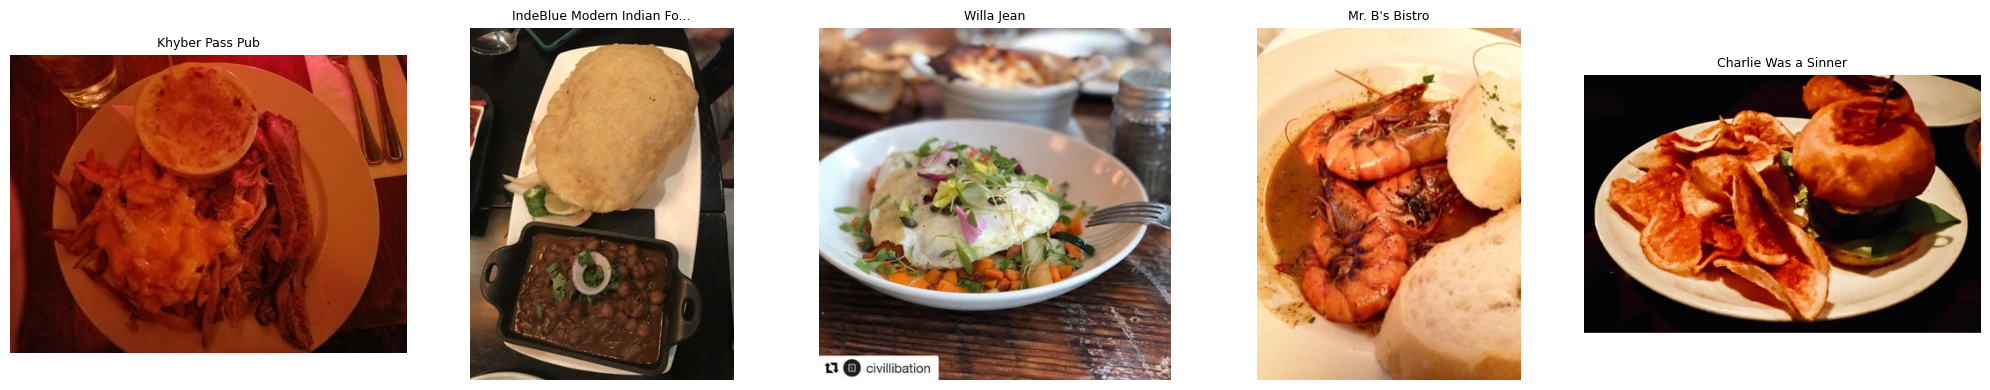


Usuario Qza0EVW1J_k0u8BIqMRbHQ  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Modo Mio - "I wish I could eat here every night. We tried Modo Mio on a Sunday night for their set priced family style dinner. We made reservations (the place isn't huge so..."
  [5*] Little Nonna's - "SOOOOOOOO good. I usually like pretty classic Italian dishes and Little Nona's has a smaller menu but everything is really a level up.   My one piece of advice ..."
  [4*] Townsend - "We came here for our anniversary dinner and had a lovely table upstairs near the window. They even wrote "Happy Anniversary" on the menu, which was a nice touch..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Harp & Crown (Philadelphia) - 4.0* - Active Life, Nightlife, Bars, American (Traditional), Bowlin...
  2. The Twisted Tail (Philadelphia) - 4.0* - Event Planning & Services, Whiskey B

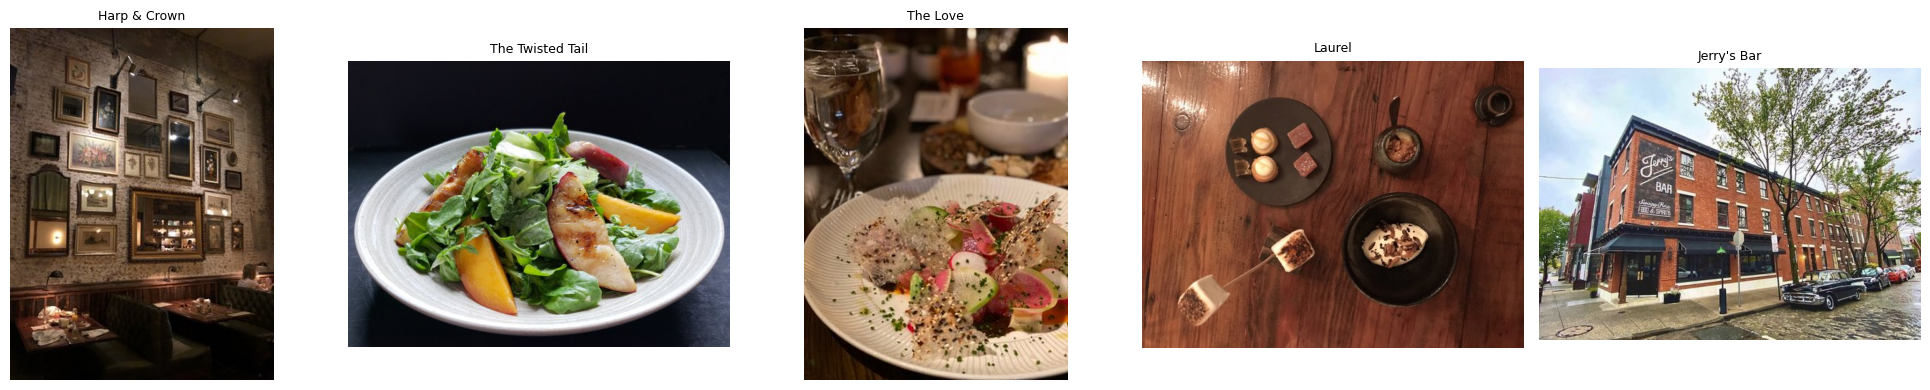


Usuario dt2VNqnnGdnYKor3uHkdlQ  |  8 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Petite Chou Bistro and Champagne Bar - "Love it!  So far our favorite brunch spot in Broad Ripple.  The atmosphere and outdoor seating are great and the ingredients and food are top notch.  I've had t..."
  [5*] Public Greens - "Yum!  Great location just off the Monon with a cute patio and long fire pit for cooler nights.  The menu is constantly changing based on local ingredients (many..."
  [5*] Milktooth - "Loved our first visit. Hour wait around noon on a Saturday in January. We ran a quick errand and then enjoyed some coffees outside while waiting (warm Jan. day ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Delicia (Indianapolis) - 4.5* - Latin American, Caribbean, Breakfast & Brunch, Restaurants, ...
  2. Good Morning Mama's (Indianapolis) - 4.0* - Restaurant

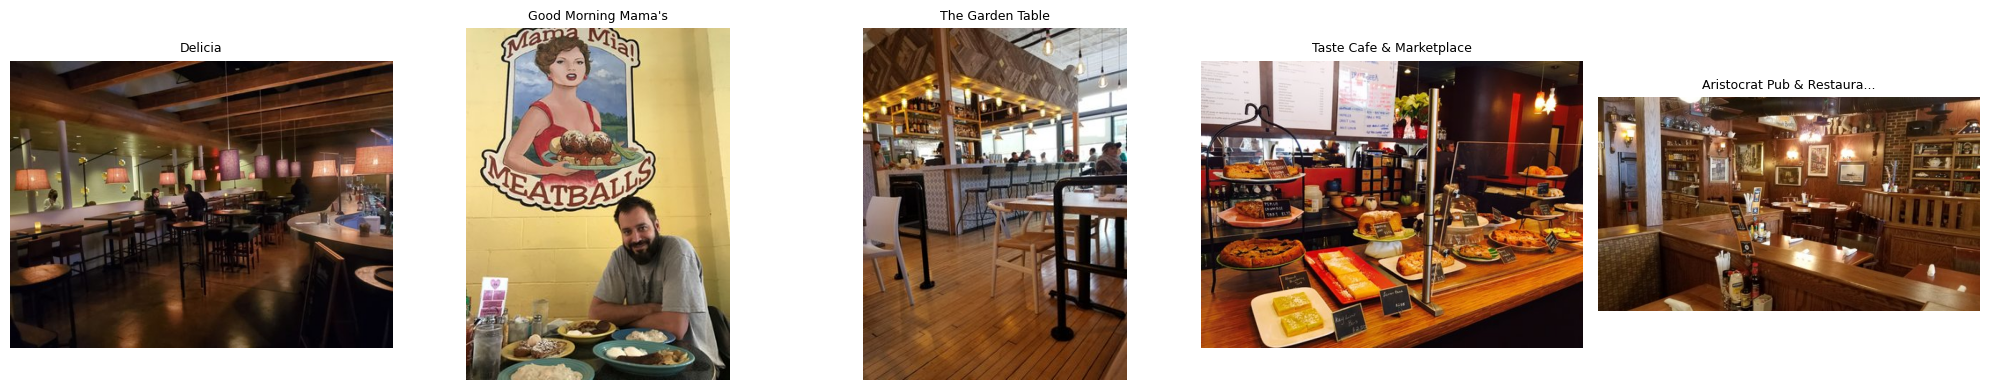


Usuario 4dwFGklOPRts-Tz2CSQZ9A  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Brocato's Sandwich Shop - "OMG this place is outrageous! If you plan on trying for the first time, plan on coming back in a week to fulfill your new addiction.   Very famous for Deviled C..."
  [5*] West Tampa Sandwich Shop - "Holy Cow! This was my very first time here and I can't believe I've waited this long!!   I had the Cuban with a ropa vieja empanada and both were unbelievably g..."
  [5*] Lee Roy Selmon's Restaurant - "The reliable Lee Roy Selmons, gotta love it! Decisions,decisions, decisions..... this is always the problem when eating here..  I really enjoy this place... I n..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Ella's Americana Folk Art Cafe (Tampa) - 4.0* - American (New), Cafes, Restaurants, Food
  2. Saigon Deli (Tampa) - 4.5* - Vietnamese, Deli

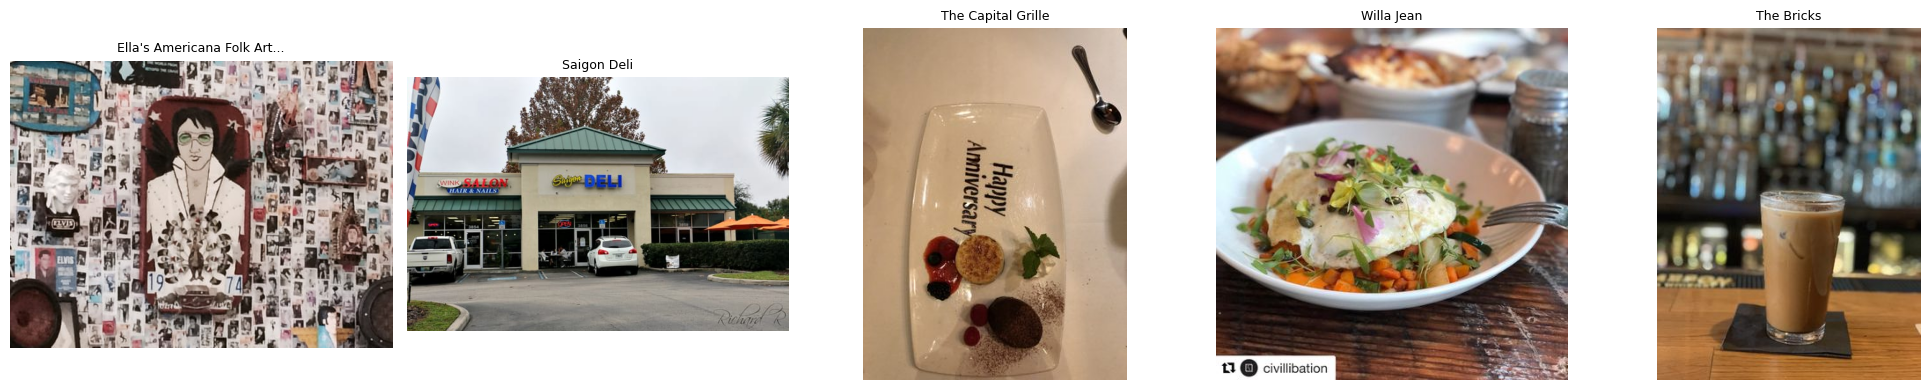


Usuario QdE2T1VEoc-QgNWKTMMixA  |  10 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Napolese Pizzeria - "Delicious pizza and a nice atmosphere. Their Paloma's were amazing and the service was great-- attentive without hovering."
  [5*] HopCat - Broad Ripple - "Two words: crack fries. They can't be beat. Hopcat boasts an impressive beer selection and they rotate regularly so there is always something new to try. It's a..."
  [5*] Quills Coffee - "Was downtown while my car was getting maintenance and needed a place to hang out. Found quills which is tucked back a bit on a side street and loved the cozy at..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Ale Emporium (Indianapolis) - 4.0* - Sports Bars, Arts & Entertainment, Restaurants, Burgers, Nig...
  2. Delicia (Indianapolis) - 4.5* - Latin American, Caribbean, Breakfast & Brunch, Restaurants, ...


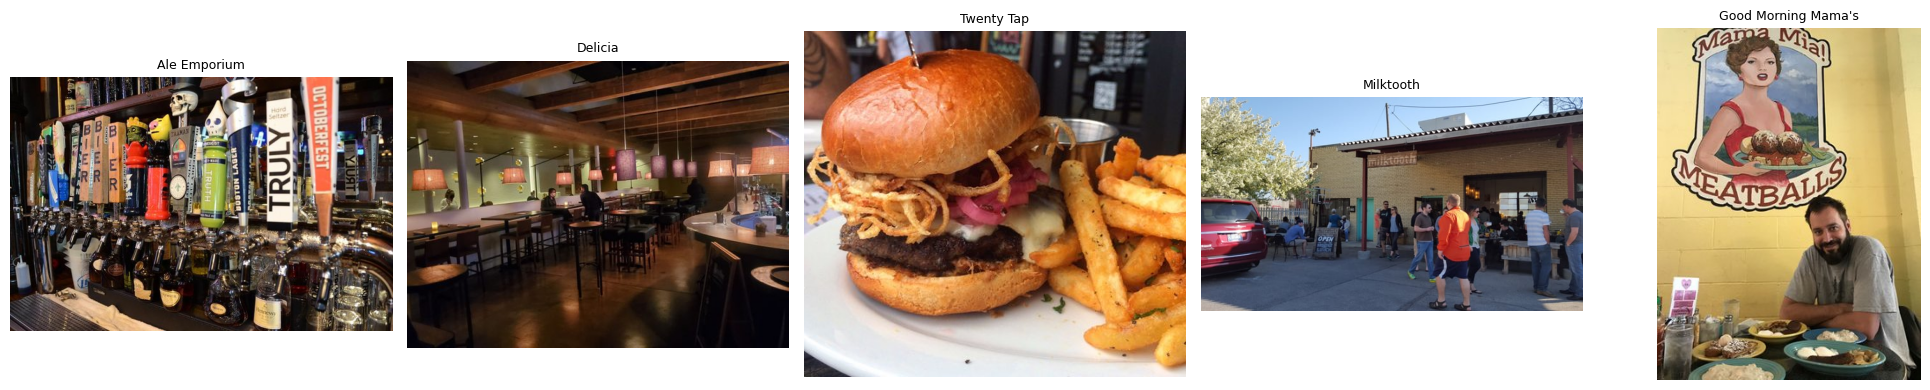

In [7]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )